Variable independiente (X): Obj Interno (meta interna de ventas del mes), Variable dependiente (Y): Ventas (Real)


### 1. Cargar el archivo crudo (sin encabezado, trae varias tablas pegadas)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

raw = pd.read_csv('Ventas.csv', header=None, encoding='utf-8-sig')
raw.shape

(153, 97)

### 2. Extraer el bloque mensual "Indicador Cumplimiento"

In [2]:
filas_ventas = {
    'Obj_Interno': 6, 'Obj_Margen_Variable': 7, 'Obj_Planta': 8,
    'Ventas': 9, 'Cumplimiento_Interno': 10, 'Cumplimiento_Planta': 11,
    'Pct_Conversion': 13,
}

n_meses = 31  # de Enero 2024 a Julio 2026

data = {}
for nombre, fila in filas_ventas.items():
    data[nombre] = raw.iloc[fila, 1:1+n_meses].tolist()

dfv = pd.DataFrame(data)

fechas = pd.date_range('2024-01-01', periods=n_meses, freq='MS')
dfv.insert(0, 'Año', fechas.year)
dfv.insert(1, 'Mes', fechas.month)
dfv.head()

,Año,Mes,Obj_Interno,Obj_Margen_Variable,Obj_Planta,Ventas,Cumplimiento_Interno,Cumplimiento_Planta,Pct_Conversion
0,2024,1,NaN,NaN,NaN,NaN,NaN,0%,NaN
1,2024,2,15,NaN,NaN,12,80%,0%,3.08%
2,2024,3,15,NaN,NaN,7,47%,0%,5.47%
3,2024,4,15,NaN,NaN,8,53%,0%,2.78%
4,2024,5,15,NaN,NaN,13,87%,0%,4.74%


### 3. Tratar columnas a tipo numérico (quitar %)

In [3]:
cols_num = list(filas_ventas.keys())
for c in cols_num:
    dfv[c] = (dfv[c].astype(str).str.replace('%', '', regex=False)
                     .str.replace(',', '', regex=False).str.strip())
    dfv[c] = pd.to_numeric(dfv[c], errors='coerce')

dfv.isna().sum()
# los nulos son reales: Enero 2024 no tenia objetivos capturados,
# y Obj_Margen_Variable / Obj_Planta empezaron a definirse hasta 2025

Año                      0
Mes                      0
Obj_Interno              1
Obj_Margen_Variable     12
Obj_Planta              12
Ventas                   1
Cumplimiento_Interno     1
Cumplimiento_Planta      0
Pct_Conversion           1
dtype: int64

### 4. Outliers con IQR (capado; no toca los NaN)

In [4]:
for c in cols_num:
    Q1, Q3 = dfv[c].quantile(0.25), dfv[c].quantile(0.75)
    IQR = Q3 - Q1
    dfv[c] = dfv[c].clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)

dfv.to_csv('Ventas_Depurado.csv', index=False)
dfv.describe()

,Año,Mes,Obj_Interno,Obj_Margen_Variable,Obj_Planta,Ventas,Cumplimiento_Interno,Cumplimiento_Planta,Pct_Conversion
count,31.00000,31.000000,30.000000,19.000000,19.000000,30.000000,30.000000,31.000000,30.000000
mean,2024.83871,5.935484,32.600000,32.105263,35.842105,27.733333,83.575000,59.354839,4.303958
std,0.77875,3.405246,11.065947,5.924476,6.792669,11.166246,16.391085,48.531466,1.393599
min,2024.00000,1.000000,15.000000,19.000000,20.000000,6.000000,48.625000,0.000000,0.970000
25%,2024.00000,3.000000,24.250000,28.000000,32.000000,20.250000,75.250000,0.000000,3.350000
50%,2025.00000,6.000000,34.000000,32.000000,37.000000,30.000000,87.000000,92.000000,4.300000
75%,2025.00000,8.500000,40.000000,36.500000,40.000000,36.750000,93.000000,100.000000,5.217500
max,2026.00000,12.000000,50.000000,42.000000,49.000000,42.000000,107.000000,111.000000,8.018750


### 5. Correlación entre las variables de Ventas (punto 5)

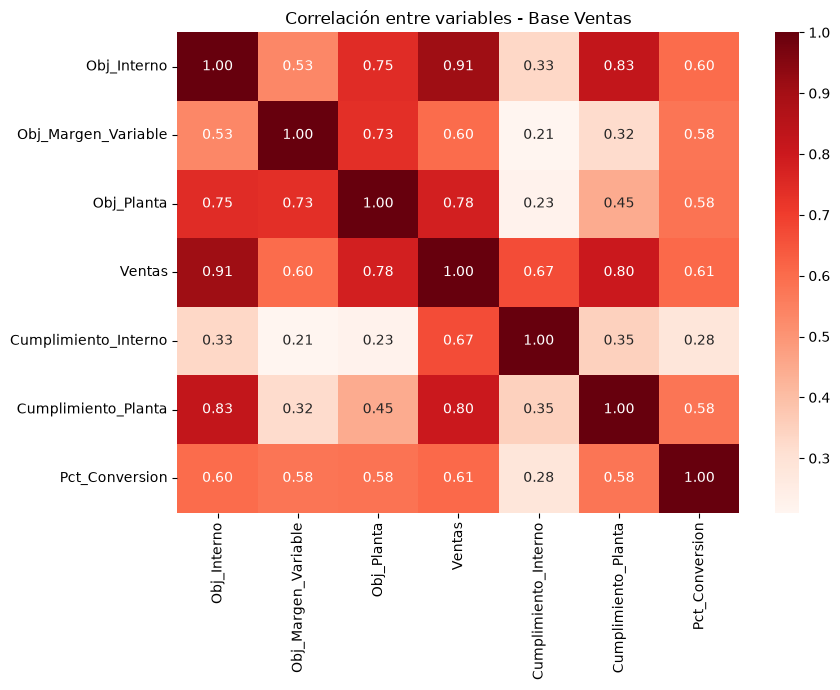

In [5]:
Corr_Ventas = abs(dfv[cols_num].corr())

plt.figure(figsize=(9,7))
sns.heatmap(Corr_Ventas, cmap='Reds', annot=True, fmt=".2f")
plt.title('Correlación entre variables - Base Ventas')
plt.tight_layout()

### 6. Modelo de regresión: X = Obj Interno, Y = Ventas
Usamos dropna porque Enero 2024 no tiene Obj_Interno capturado (dato faltante real, no error).

In [6]:
df_modelo = dfv.dropna(subset=['Obj_Interno', 'Ventas']).reset_index(drop=True)

Vars_Indep = df_modelo[['Obj_Interno']]
Var_Dep = df_modelo['Ventas']

model_ventas = LinearRegression()
model_ventas.fit(X=Vars_Indep, y=Var_Dep)
model_ventas.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Obj_Interno'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.91766164]),
 'rank_': np.int64(1),
 'singular_': array([59.59194576]),
 'intercept_': np.float64(-2.1824359840805094)}

### 7. R², predicciones y gráfica

R²: 0.8270425912954329


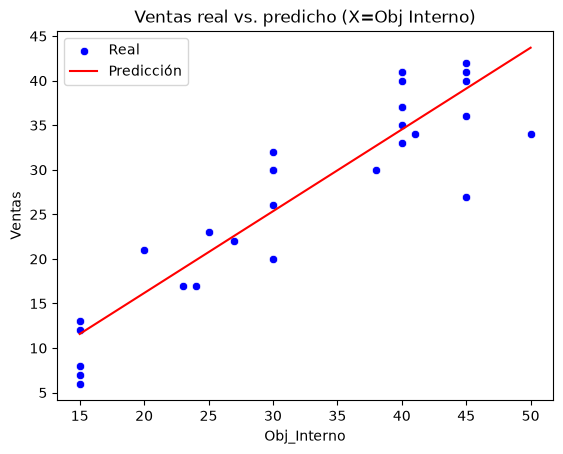

In [9]:
r2_ventas = model_ventas.score(Vars_Indep, Var_Dep)
print("R²:", r2_ventas)

y_pred = model_ventas.predict(X=Vars_Indep)
df_modelo['Predicciones_Ventas'] = y_pred

sns.scatterplot(x='Obj_Interno', y='Ventas', color="blue", data=df_modelo, label='Real')
sns.lineplot(x='Obj_Interno', y='Predicciones_Ventas', color="red", data=df_modelo, label='Predicción')
plt.title('Ventas real vs. predicho (X=Obj Interno)')
plt.legend()

### 8. Coeficiente de correlación

In [8]:
coef_correl_ventas = np.sqrt(r2_ventas)
coef_correl_ventas

np.float64(0.9094188206186591)